# Clustering auf Farbpaletten

Wir wollen Clusterint verwenden um die Anzahl an verwendeten Farben in einem Bild zu reduzieren.

Nutzen Sie cv2 um das `castle.jpg` Bild zu laden. Plotten Sie dieses einmal mit matplotlib (siehe vergangene Übungen dafür).
Mit `plt.figure(figsize=(8, 6), dpi=100)` können Sie die Plotgröße erhöhen.

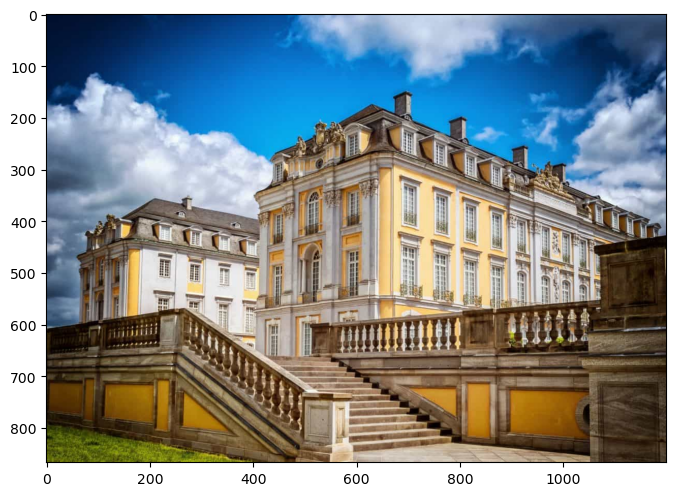

In [ ]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

# ADD CODE HERE

im = cv2.imread("castle.jpg")
plt.figure(figsize=(8,6), dpi=100)
plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)) #statischer analysator ist nicht damit zufrieden, da angeblich img none sein kann


Jeder Pixel ist ein 3 dimensionaler Vektor. Mit `np.unique` können Sie zählen, wieviele unterschiedliche Farben es im Bild gibt.
Vorsicht: Mit der Axis kommt man hier leicht durcheinander.

In [ ]:
# Achtung: mit der Axis kommt man hier sehr leicht durcheinander. 158822

# ADD CODE HERE
pixels = im.reshape(-1, 3) #letzte dimension muss 3 sein (3 werte für jedes pixel und -1 heißt, dass die erste dimension wird automatisch berechnet)
# reshape(-1, n) - сделай строки длины n а количество строк посчитай автоматически

uniq_colors = np.unique(pixels, axis=0)
print(len(uniq_colors))



158822


Nutzen Sie nun KMeans Clustering, um die Farben zu 64 Clustern zusammenzufassen.

In [ ]:
from sklearn.cluster import KMeans

# ADD CODE HERE
#nsamples, nfeatures = objects, features of obj
kmeans = KMeans(n_clusters=64, random_state=1).fit(pixels)


Mit der Eigenschaft `cluster_centers_` kommen Sie an die Centroids der 64 Cluster. Diese sind erstmal noch fraktional. Mit `np.rint` können Sie sie runden und mit `.astype(np.uint8)` wieder in in den passenden Typ umwandeln.
Erstellen Sie nun ein neues Bild, bei dem du jedem Pixel als Farben den passenden Cluster Centroid zuweist.
Plotten Sie das neue Bild.

64


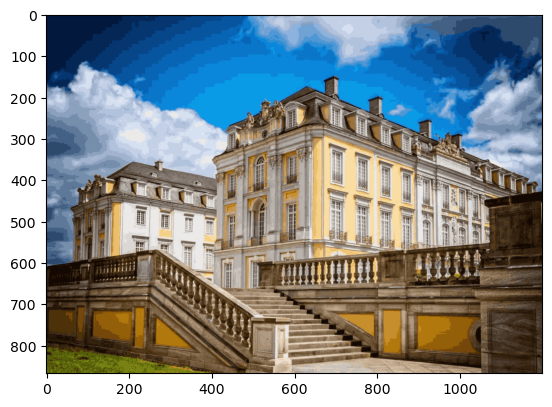

In [ ]:
# ADD CODE HERE

centers = np.rint(kmeans.cluster_centers_).astype(np.uint8)
clusters = kmeans.labels_

count = 0
for row in range(0,len(im)):
    for col in range(0,len(im[row])):
        cluster = clusters[count]
        im[row][col] = centers[cluster]
        count+=1
plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))


print(len(np.unique(im.reshape(-1, 3), axis=0)))


#man könnte das auch einfacher lösen
#clusters[labels].reshape(rgb_im.shape)

Sie können versuchen die Cluster Centroids zu plotten. Zum Beispiel mit `matplotlib.patches.Rectangle`.

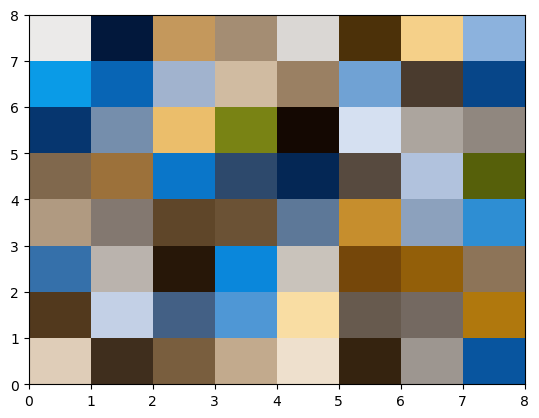

In [44]:
import matplotlib.patches as mpatch

fig, ax = plt.subplots()

# ADD CODE HERE
count = 0
for x in range(8):
    for y in range(8):
        cluster = centers[count]
        count +=1
        rect = mpatch.Rectangle((x,y), width = 1, height = 1)
        modified = list(map(lambda color_val: color_val/255, cluster))
        #bgr -> rgb (dreieckvertausch)
        r = modified[2]
        modified[2] = modified[0]
        modified[0] = r
        rect.set_facecolor(modified)
        ax.add_patch(rect)

ax.set_xlim(0, 8)
ax.set_ylim(0, 8)
plt.show()

Könnten wir hier auch Spectral Clustering nutzen? Was würden wir da als Ergebnis erwarten?

Optional können Sie auch versuchen, das zum Laufen zu bringen (mit ein paar Tricks klappt das).

In [ ]:
# ADD CODE HERE

'''
Lösungsansatz
1)man könnte ein graph von farbähnlichkeit bilden
2)laplace matrix = diagonal - adjazenzmatrix
3)eigene vektoren
4)kmeans
'''